##### Data preprocessing (Winter months - January)

##### Load in and read the pickle files (Load demand)

In [ ]:
import pickle
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.expand_frame_repr', False)

In [ ]:
# Combined Data from 2013 - 2019 (7 years)

error_data = {}

for year in range(2013, 2021):
  with open(f'error_demand_{year}.pickle', 'rb') as file:
    error_data[f'{year}'] = pickle.load(file)

ed = [error_data['2013'], error_data['2014'], error_data['2015'], error_data['2016'], error_data['2017'], error_data['2018'], error_data['2019']]

merged_error_demand = pd.concat(ed, ignore_index = False)

merged_error_demand = merged_error_demand.reset_index()

In [ ]:
# Extract the month and create a new column
merged_error_demand['month'] = merged_error_demand['Date'].dt.month

# Extract the year and create a new column
merged_error_demand['year'] = merged_error_demand['Date'].dt.year

# Extract the month name and create a new column
merged_error_demand['month_name'] = merged_error_demand['Date'].dt.month_name()

# Extract the day of the month and create a new column
merged_error_demand['day_of_month'] = merged_error_demand['Date'].dt.day

# Extract the hour and create a new column
merged_error_demand['hour'] = merged_error_demand['Date'].dt.hour

# Extract the day of the week (numeric) and create a new column
merged_error_demand['day_of_week_num'] = merged_error_demand['Date'].dt.dayofweek

# Extract the day of the week (name) and create a new column
merged_error_demand['day_of_week_name'] = merged_error_demand['Date'].dt.day_name()

# Filter out data for the month of January only
merged_error_demand_Jan = merged_error_demand.loc[merged_error_demand['month_name'] == 'January']

merged_error_demand_Jan = merged_error_demand_Jan.set_index('Date')
print(merged_error_demand_Jan)

                     error_demand  month  year month_name  day_of_month  hour  day_of_week_num day_of_week_name
Date                                                                                                           
2013-01-01 00:00:00    162.494414      1  2013    January             1     0                1          Tuesday
2013-01-01 01:00:00    103.697598      1  2013    January             1     1                1          Tuesday
2013-01-01 02:00:00     62.113301      1  2013    January             1     2                1          Tuesday
2013-01-01 03:00:00    291.140332      1  2013    January             1     3                1          Tuesday
2013-01-01 04:00:00    406.263691      1  2013    January             1     4                1          Tuesday
...                           ...    ...   ...        ...           ...   ...              ...              ...
2019-01-31 19:00:00   1331.584922      1  2019    January            31    19                3         T

##### Part I

* Exploration of the load PDFs for **a specific day** of a **specific month (January)** in a **specific year**

In [ ]:
# Day - 21st, Month - January, Years (2013 to 2019)

Jan_filtered_I_2013 = merged_error_demand_Jan[(merged_error_demand_Jan['day_of_month'] == 21) & (merged_error_demand_Jan['year'] == 2013)]

Jan_filtered_I_2014 = merged_error_demand_Jan[(merged_error_demand_Jan['day_of_month'] == 21) & (merged_error_demand_Jan['year'] == 2014)]

Jan_filtered_I_2015 = merged_error_demand_Jan[(merged_error_demand_Jan['day_of_month'] == 21) & (merged_error_demand_Jan['year'] == 2015)]

Jan_filtered_I_2016 = merged_error_demand_Jan[(merged_error_demand_Jan['day_of_month'] == 21) & (merged_error_demand_Jan['year'] == 2016)]

Jan_filtered_I_2017 = merged_error_demand_Jan[(merged_error_demand_Jan['day_of_month'] == 21) & (merged_error_demand_Jan['year'] == 2017)]

Jan_filtered_I_2018 = merged_error_demand_Jan[(merged_error_demand_Jan['day_of_month'] == 21) & (merged_error_demand_Jan['year'] == 2018)]

Jan_filtered_I_2019 = merged_error_demand_Jan[(merged_error_demand_Jan['day_of_month'] == 21) & (merged_error_demand_Jan['year'] == 2019)]

In [ ]:
Jan_filtered_I_2013

,error_demand,month,year,month_name,day_of_month,hour,day_of_week_num,day_of_week_name
Date,,,,,,,,
2013-01-21 00:00:00,44.966445,1,2013,January,21,0,0,Monday
2013-01-21 01:00:00,77.647383,1,2013,January,21,1,0,Monday
2013-01-21 02:00:00,8.237754,1,2013,January,21,2,0,Monday
2013-01-21 03:00:00,59.944102,1,2013,January,21,3,0,Monday
2013-01-21 04:00:00,165.571816,1,2013,January,21,4,0,Monday
2013-01-21 05:00:00,207.289316,1,2013,January,21,5,0,Monday
2013-01-21 06:00:00,287.336777,1,2013,January,21,6,0,Monday
2013-01-21 07:00:00,155.409141,1,2013,January,21,7,0,Monday
2013-01-21 08:00:00,254.306250,1,2013,January,21,8,0,Monday


In [ ]:
# Demand Data filtered

Jan_load_data = Jan_filtered_I_2019['error_demand']

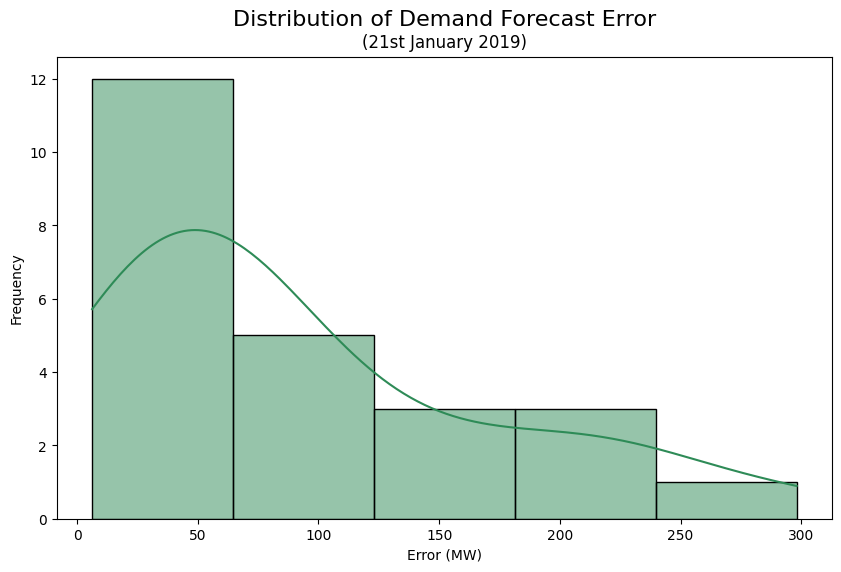

In [ ]:
# Load distribution plots

# Create DataFrame
df = pd.DataFrame(Jan_load_data)

# Plot histogram
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='error_demand', bins=5, kde=True, color = 'seagreen')
plt.title('Distribution of Demand Forecast Error\n', fontsize=16)  # Adding \n for a line break
plt.xlabel('Error (MW)')
plt.ylabel('Frequency')

# Add subtitle
plt.text(0.5, 1.02, '(21st January 2019)', ha='center', fontsize=12, transform=plt.gca().transAxes)

# Save the figure with high resolution
plt.savefig('Forecast Load distribution (January 2019).png', dpi=300, bbox_inches='tight')

plt.show()

In [ ]:
# List to store each run of the code in the next code cell
# Jan_load_data = Jan_filtered_I_X['demand']. X is changed from 2013 to 2019

compiled_load_stats = []

In [ ]:
Jan_load_data = Jan_filtered_I_2019['error_demand']

In [ ]:
# PDF fitting and testing for Load demand data

# Dictionary to store goodness-of-fit statistics
load_distribution_results = {}
data = Jan_load_data

# Distributions to consider
distribution_list = ['norm', 'lognorm', 'skewnorm', 'gamma', 'cauchy', 'rayleigh', 'loggamma', 'beta']

# Iterate through distributions
for distribution in distribution_list:
    # Fit the data
    if distribution in ['norm', 'lognorm']:
        params = getattr(stats, distribution).fit(data)
        fitted_distribution = getattr(stats, distribution)(*params)
    else:
        params = getattr(stats, distribution).fit(data)
        fitted_distribution = getattr(stats, distribution)(*params[:-2], loc=params[-2], scale=params[-1])

    # Generate PDFs for the fitted distributions
    x = np.linspace(data.min(), data.max(), 100)
    pdf = fitted_distribution.pdf(x)

    # Perform goodness-of-fit tests
    ks_statistic, ks_p_value = stats.kstest(data, distribution, args=params)
    cvm_result_obj = stats.cramervonmises(data, fitted_distribution.cdf)

    # Extract statistic and p-value from CramerVonMisesResult object
    cvm_statistic, cvm_p_value = cvm_result_obj.statistic, cvm_result_obj.pvalue

    load_distribution_results[distribution.capitalize()] = {'KS': [ks_statistic, ks_p_value], 'CvM': [cvm_statistic, cvm_p_value]}

# Display goodness-of-fit results
for distribution, results in load_distribution_results.items():
    print(f'{distribution}: KS Statistic = {results["KS"][0]}, p-value = {results["KS"][1]}, CvM Statistic = {results["CvM"][0]}, p-value = {results["CvM"][1]}')

compiled_load_stats.append(load_distribution_results)

Norm: KS Statistic = 0.22359453907380467, p-value = 0.15533416773620579, CvM Statistic = 0.22954249418633088, p-value = 0.21731590099448728
Lognorm: KS Statistic = 0.0761397279182936, p-value = 0.9971333690953098, CvM Statistic = 0.027479868993319195, p-value = 0.9855031092192261
Skewnorm: KS Statistic = 0.19577538658420957, p-value = 0.2783446709476325, CvM Statistic = 0.17095274998332152, p-value = 0.3331657813448352
Gamma: KS Statistic = 0.15510516950640732, p-value = 0.5584540877150741, CvM Statistic = 0.09845687108200903, p-value = 0.596350166062969
Cauchy: KS Statistic = 0.18915057102593386, p-value = 0.31594216451375523, CvM Statistic = 0.212684183254837, p-value = 0.2449108203124044
Rayleigh: KS Statistic = 0.22848833680429026, p-value = 0.13901896593593233, CvM Statistic = 0.2422664714598074, p-value = 0.198877980512023
Loggamma: KS Statistic = 0.2246800724839378, p-value = 0.1515897937148274, CvM Statistic = 0.23263419463184196, p-value = 0.21265915515054612
Beta: KS Statisti

/usr/local/lib/python3.10/dist-packages/scipy/stats/_continuous_distns.py:719: RuntimeWarning: invalid value encountered in sqrt
  sk = 2*(b-a)*np.sqrt(a + b + 1) / (a + b + 2) / np.sqrt(a*b)


In [ ]:
# Checking the length of 'compiled_load_stats'. The length should be 7.

print(len(compiled_load_stats))

7


In [ ]:
# Convert list of dictionaries to DataFrame
# Set display options
pd.set_option('display.max_columns', None)  # Show all columns
pd.set_option('display.max_rows', None)     # Show all rows

# Convert to DataFrame
df_a = pd.DataFrame(compiled_load_stats)

# Write DataFrame to CSV
df_a.to_csv('compiled_loaderror_stats.csv', index=False)

* Result plotting for each PDF **(KS test & CvM)** for each year (2013 to 2019)

In [ ]:
# Import the csv result

compiled_stats_load = pd.read_csv('compiled_loaderror_stats.csv')

In [ ]:
# Unpacking each cell to a wide format.
import ast

# Function to expand dictionary values into separate columns
def expand_dict_values(row, column_name):
    expanded_values = ast.literal_eval(row[column_name])
    for key, value in expanded_values.items():
        for i, v in enumerate(value):
            row[f"{column_name}_{key}_{i+1}"] = v
    return row

# Convert the dictionary to a DataFrame
df = pd.DataFrame(compiled_stats_load)

# Iterate over each PDF column and expand values
for pdf in df.columns:
    df = df.apply(lambda row: expand_dict_values(row, pdf), axis=1)

# Drop the original PDF columns
df.drop(columns=list(compiled_stats_load.keys()), inplace=True)

# Iterate over column names and replace '1' with 'stats' and '2' with 'pvalues'
df.columns = df.columns.str.replace('1', 'stats').str.replace('2', 'pvalues')

# Print the updated DataFrame
print(df)

   Norm_KS_stats  Norm_KS_pvalues  Norm_CvM_stats  Norm_CvM_pvalues  Lognorm_KS_stats  Lognorm_KS_pvalues  Lognorm_CvM_stats  Lognorm_CvM_pvalues  Skewnorm_KS_stats  Skewnorm_KS_pvalues  Skewnorm_CvM_stats  Skewnorm_CvM_pvalues  Gamma_KS_stats  Gamma_KS_pvalues  Gamma_CvM_stats  Gamma_CvM_pvalues  Cauchy_KS_stats  Cauchy_KS_pvalues  Cauchy_CvM_stats  Cauchy_CvM_pvalues  Rayleigh_KS_stats  Rayleigh_KS_pvalues  Rayleigh_CvM_stats  Rayleigh_CvM_pvalues  Loggamma_KS_stats  Loggamma_KS_pvalues  Loggamma_CvM_stats  Loggamma_CvM_pvalues  Beta_KS_stats  Beta_KS_pvalues  Beta_CvM_stats  Beta_CvM_pvalues
0       0.137449         0.704543        0.114123          0.523270          0.124054            0.810561           0.061780             0.807504           0.118925             0.847243            0.052448              0.865827        0.212038          0.199887         0.244630           0.195657         0.185415           0.338611          0.158298            0.367147           0.131505        

In [ ]:
# Filtering 'pvalues' columns only

import pandas as pd

# Filtering 'pvalues' columns only
pvalues_columns = [col for col in df.columns if 'pvalues' in col]

# Subset the DataFrame with the filtered column names
df_pvalues = df[pvalues_columns].copy()  # Make a copy to avoid modifying the original DataFrame

# Create a range of datetime values from 2013 to 2019
years = ['2013', '2014', '2015', '2016', '2017', '2018', '2019']

# Add the 'Year' column to the DataFrame using .loc to avoid the warning
df_pvalues.loc[:, 'Year'] = years

# Rearrange the columns so that 'Year' is the first column
df_pvalues = df_pvalues[['Year'] + [col for col in df_pvalues.columns if col != 'Year']]

# Print the subsetted DataFrame
print(df_pvalues)

   Year  Norm_KS_pvalues  Norm_CvM_pvalues  Lognorm_KS_pvalues  Lognorm_CvM_pvalues  Skewnorm_KS_pvalues  Skewnorm_CvM_pvalues  Gamma_KS_pvalues  Gamma_CvM_pvalues  Cauchy_KS_pvalues  Cauchy_CvM_pvalues  Rayleigh_KS_pvalues  Rayleigh_CvM_pvalues  Loggamma_KS_pvalues  Loggamma_CvM_pvalues  Beta_KS_pvalues  Beta_CvM_pvalues
0  2013         0.704543          0.523270            0.810561             0.807504             0.847243              0.865827          0.199887           0.195657           0.338611            0.367147             0.752939              0.559571             0.698142              0.538830         0.193530          0.136740
1  2014         0.380795          0.321465            0.985204             0.997292             0.887588              0.856248          0.989596           0.988577           0.487957            0.328387             0.421446              0.365115             0.367276              0.309591         0.120363          0.102847
2  2015         0.832752    

In [ ]:
# Reshaping 'p_values' columns (transforming to a long format)

# Reshape the DataFrame to long format
df_long = pd.melt(df_pvalues, id_vars='Year', var_name='PDF', value_name='Value')

# Extract PDF type and Stat type from 'PDF' column
df_long[['PDF', 'Pvalue', '_']] = df_long['PDF'].str.split('_', expand=True)

# Pivot the DataFrame to wide format with KS and CvM stats as separate columns
df_pivot_pvalues = df_long.pivot_table(index=['Year', 'PDF'], columns='Pvalue', values='Value').reset_index()

# Rename the columns
df_pivot_pvalues.columns.name = None
df_pivot_pvalues.columns = ['Year', 'PDF', 'CvM_pvalues', 'KS_pvalues']

print(df_pivot_pvalues)

    Year       PDF  CvM_pvalues  KS_pvalues
0   2013      Beta     0.136740    0.193530
1   2013    Cauchy     0.367147    0.338611
2   2013     Gamma     0.195657    0.199887
3   2013  Loggamma     0.538830    0.698142
4   2013   Lognorm     0.807504    0.810561
5   2013      Norm     0.523270    0.704543
6   2013  Rayleigh     0.559571    0.752939
7   2013  Skewnorm     0.865827    0.847243
8   2014      Beta     0.102847    0.120363
9   2014    Cauchy     0.328387    0.487957
10  2014     Gamma     0.988577    0.989596
11  2014  Loggamma     0.309591    0.367276
12  2014   Lognorm     0.997292    0.985204
13  2014      Norm     0.321465    0.380795
14  2014  Rayleigh     0.365115    0.421446
15  2014  Skewnorm     0.856248    0.887588
16  2015      Beta     0.805690    0.772631
17  2015    Cauchy     0.753456    0.553444
18  2015     Gamma     0.113097    0.167494
19  2015  Loggamma     0.831219    0.844431
20  2015   Lognorm     0.956684    0.854109
21  2015      Norm     0.833880 

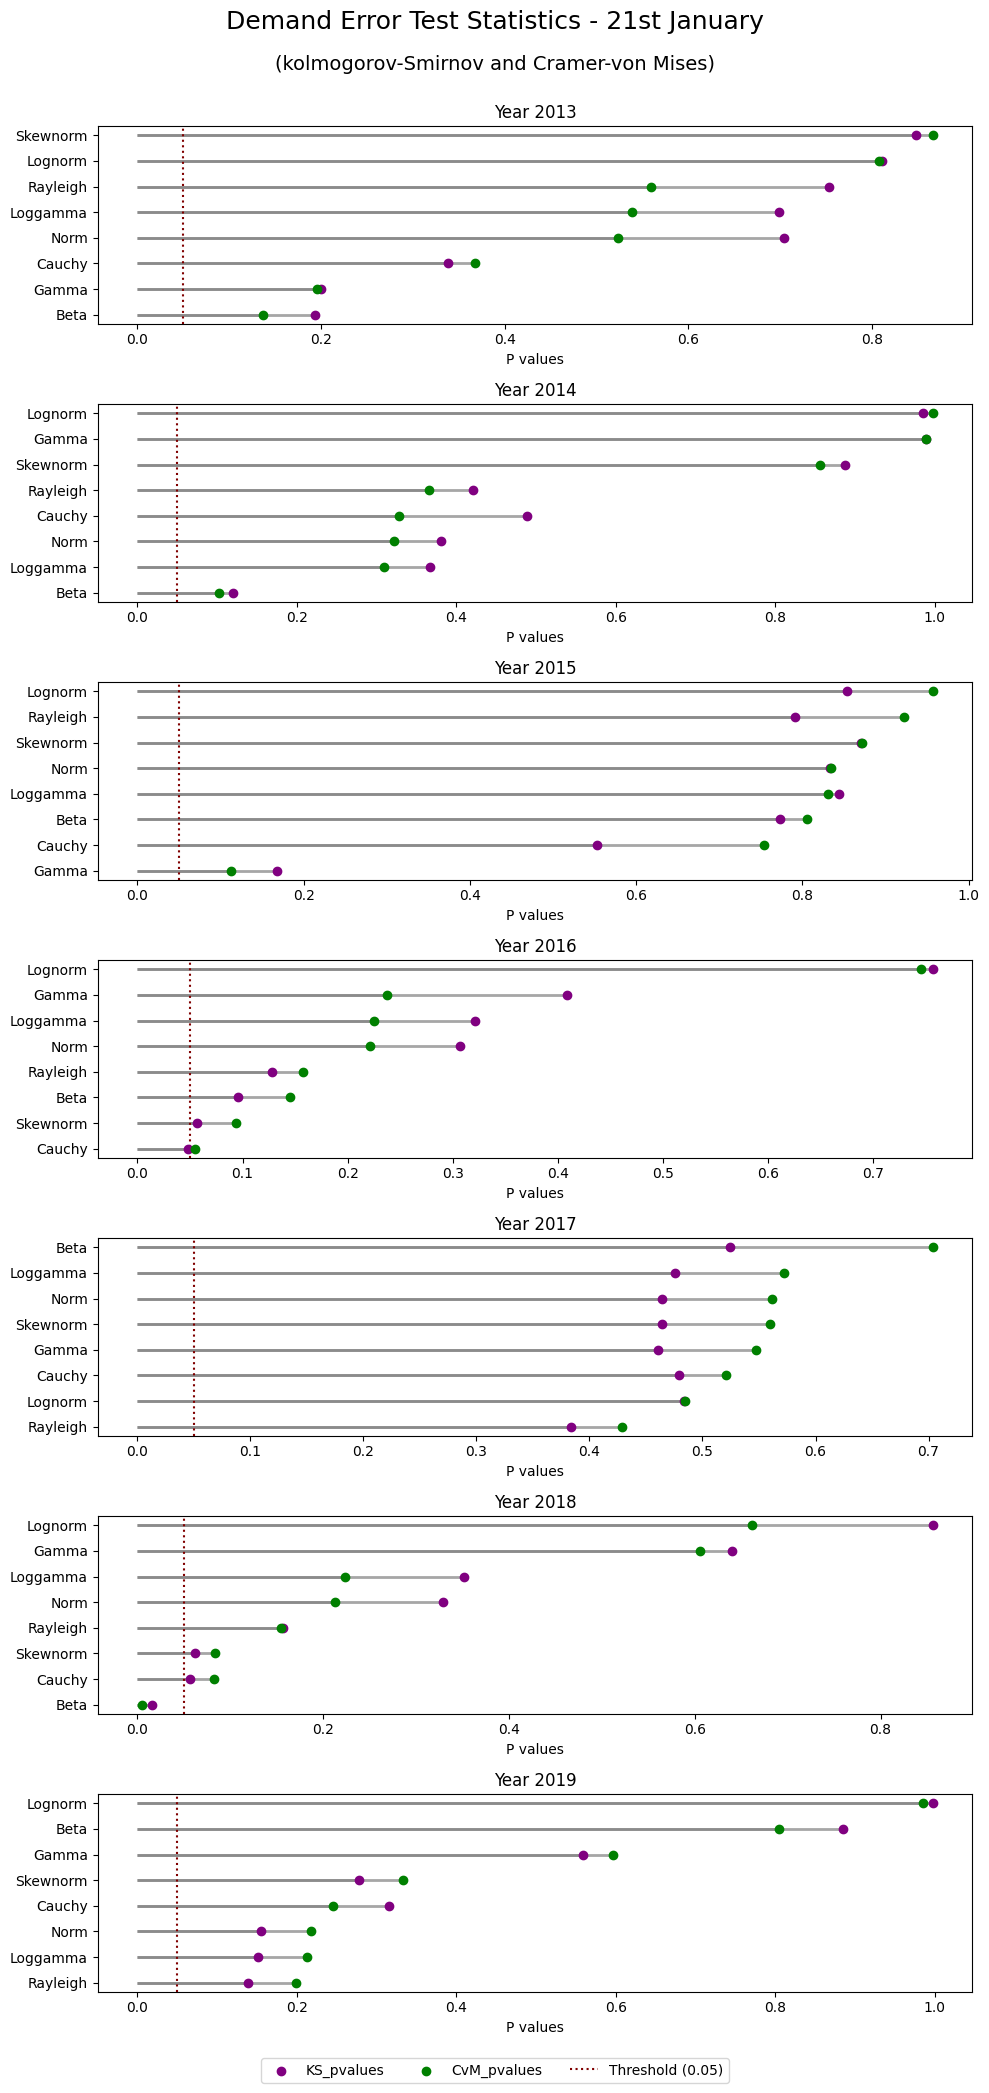

In [ ]:
# Plot of the 'Goodness of fit' for each PDF
# Convert data to DataFrame
df_1 = df_pivot_pvalues

# Sort DataFrame by 'KS_pvalues' and 'CvM_pvalues' in descending order
df_sorted = df_1.sort_values(by=['CvM_pvalues', 'KS_pvalues'], ascending=True)

# Create a lollipop plot
fig, axs = plt.subplots(7, 1, figsize=(10, 20))

# Iterate over each year
for i, year in enumerate(df_1['Year'].unique()):
    # Filter data for the current year
    year_data = df_sorted[df_sorted['Year'] == year]

    # Set up subplot
    ax = axs[i]

    # Plot the KS pvalues
    ax.scatter(year_data['KS_pvalues'], year_data['PDF'], color='purple', label='KS_pvalues', zorder=5)
    for _, row in year_data.iterrows():
        ax.hlines(row['PDF'], 0, row['KS_pvalues'], color='grey', alpha=0.7, linewidth=2, zorder=0)

    # Plot the CvM pvalues
    ax.scatter(year_data['CvM_pvalues'], year_data['PDF'], color='green', label='CvM_pvalues', zorder=5)
    for _, row in year_data.iterrows():
        ax.hlines(row['PDF'], 0, row['CvM_pvalues'], color='grey', alpha=0.7, linewidth=2, zorder=0)

    # Set labels and title
    ax.set_xlabel('P values')
    ax.set_ylabel('')
    ax.set_title(f'Year {year}')

    # Place a vertical dotted line at the value of 0.05
    ax.axvline(x=0.05, color='maroon', linestyle='dotted', label='Threshold (0.05)')

    # Disable legend
    ax.legend().remove()

# Add a title and subtitle to the figure
fig.suptitle('Demand Error Test Statistics - 21st January', fontsize=18, y=1.02)
fig.text(0.5, 0.99, '(kolmogorov-Smirnov and Cramer-von Mises)', ha='center', fontsize=14)

# Add legend at the bottom
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.02), ncol=3)

# Adjust layout
plt.tight_layout()

# Save the figure with high resolution
plt.savefig('Loaderror_test_stats(pvalues_2013_2019).png', dpi=300, bbox_inches='tight')

plt.show()

In [ ]:
# Filtering for the 'stats' columns

stats_columns = [col for col in df.columns if 'stats' in col]

# Subset the DataFrame with the filtered column names
df_stats = df[stats_columns].copy()

# Create a range of datetime values from 2013 to 2019
years = ['2013', '2014', '2015', '2016', '2017', '2018', '2019']

# Add the 'Year' column to the DataFrame
df_stats.loc[:, 'Year'] = years

# Rearrange the columns so that 'Year' is the first column
df_stats = df_stats[['Year'] + [col for col in df_stats.columns if col != 'Year']]

# Print the subsetted DataFrame
print(df_stats)

   Year  Norm_KS_stats  Norm_CvM_stats  Lognorm_KS_stats  Lognorm_CvM_stats  Skewnorm_KS_stats  Skewnorm_CvM_stats  Gamma_KS_stats  Gamma_CvM_stats  Cauchy_KS_stats  Cauchy_CvM_stats  Rayleigh_KS_stats  Rayleigh_CvM_stats  Loggamma_KS_stats  Loggamma_CvM_stats  Beta_KS_stats  Beta_CvM_stats
0  2013       0.137449        0.114123          0.124054           0.061780           0.118925            0.052448        0.212038         0.244630         0.185415          0.158298           0.131505            0.106057           0.138224            0.110591       0.213556        0.297912
1  2014       0.178882        0.175674          0.087442           0.020377           0.112677            0.054000        0.084581         0.026170         0.164022          0.172857           0.172999            0.159014           0.180923            0.180680       0.234686        0.341978
2  2015       0.121000        0.057584          0.117916           0.035783           0.115442            0.051413        0.

In [ ]:
# Reshaping the stats column

# Reshape the DataFrame to long format
df_long = pd.melt(df_stats, id_vars='Year', var_name='PDF', value_name='Value')

# Extract PDF type and Stat type from 'PDF' column
df_long[['PDF', 'Stat', '_']] = df_long['PDF'].str.split('_', expand=True)

# Pivot the DataFrame to wide format with KS and CvM stats as separate columns
df_pivot_kstats = df_long.pivot_table(index=['Year', 'PDF'], columns='Stat', values='Value').reset_index()

# Rename the columns
df_pivot_kstats.columns.name = None
df_pivot_kstats.columns = ['Year', 'PDF', 'CvM_stats', 'KS_stats']

# Arrange PDFs in ascending order of KS_stats and CvM_stats for each year
df_pivot_kstats = df_pivot_kstats.groupby('Year').apply(lambda x: x.sort_values(by=['CvM_stats', 'KS_stats'])).reset_index(drop=True)

# Write to a csv file
df_pivot_kstats.to_csv('Loaderror_KS_CvM_stats_2013-2019.csv')

print(df_pivot_kstats)

    Year       PDF  CvM_stats  KS_stats
0   2013  Skewnorm   0.052448  0.118925
1   2013   Lognorm   0.061780  0.124054
2   2013  Rayleigh   0.106057  0.131505
3   2013  Loggamma   0.110591  0.138224
4   2013      Norm   0.114123  0.137449
5   2013    Cauchy   0.158298  0.185415
6   2013     Gamma   0.244630  0.212038
7   2013      Beta   0.297912  0.213556
8   2014   Lognorm   0.020377  0.087442
9   2014     Gamma   0.026170  0.084581
10  2014  Skewnorm   0.054000  0.112677
11  2014  Rayleigh   0.159014  0.172999
12  2014    Cauchy   0.172857  0.164022
13  2014      Norm   0.175674  0.178882
14  2014  Loggamma   0.180680  0.180923
15  2014      Beta   0.341978  0.234686
16  2015   Lognorm   0.035783  0.117916
17  2015  Rayleigh   0.042879  0.126694
18  2015  Skewnorm   0.051413  0.115442
19  2015      Norm   0.057584  0.121000
20  2015  Loggamma   0.058008  0.119334
21  2015      Beta   0.062068  0.129019
22  2015    Cauchy   0.070454  0.155724
23  2015     Gamma   0.327133  0.220207


##### Part II

* Hourly Analysis (Load Demand)

In [ ]:
import pickle

# Create a copy of the dataframe
Jan_data = merged_error_demand_Jan.copy()

# Initialize an empty dictionary to store the load demand and price data for each hour (Jan)
hourly_data_Jan = {}

# Iterate through hours from 0 to 23
for hour in range(24):
    # Filter the data for the current hour and store it in the dictionary (The value of each key is a the Load demand)
    hourly_data_Jan[f'Hour_{hour}'] = Jan_data[Jan_data['hour'] == hour]['error_demand']

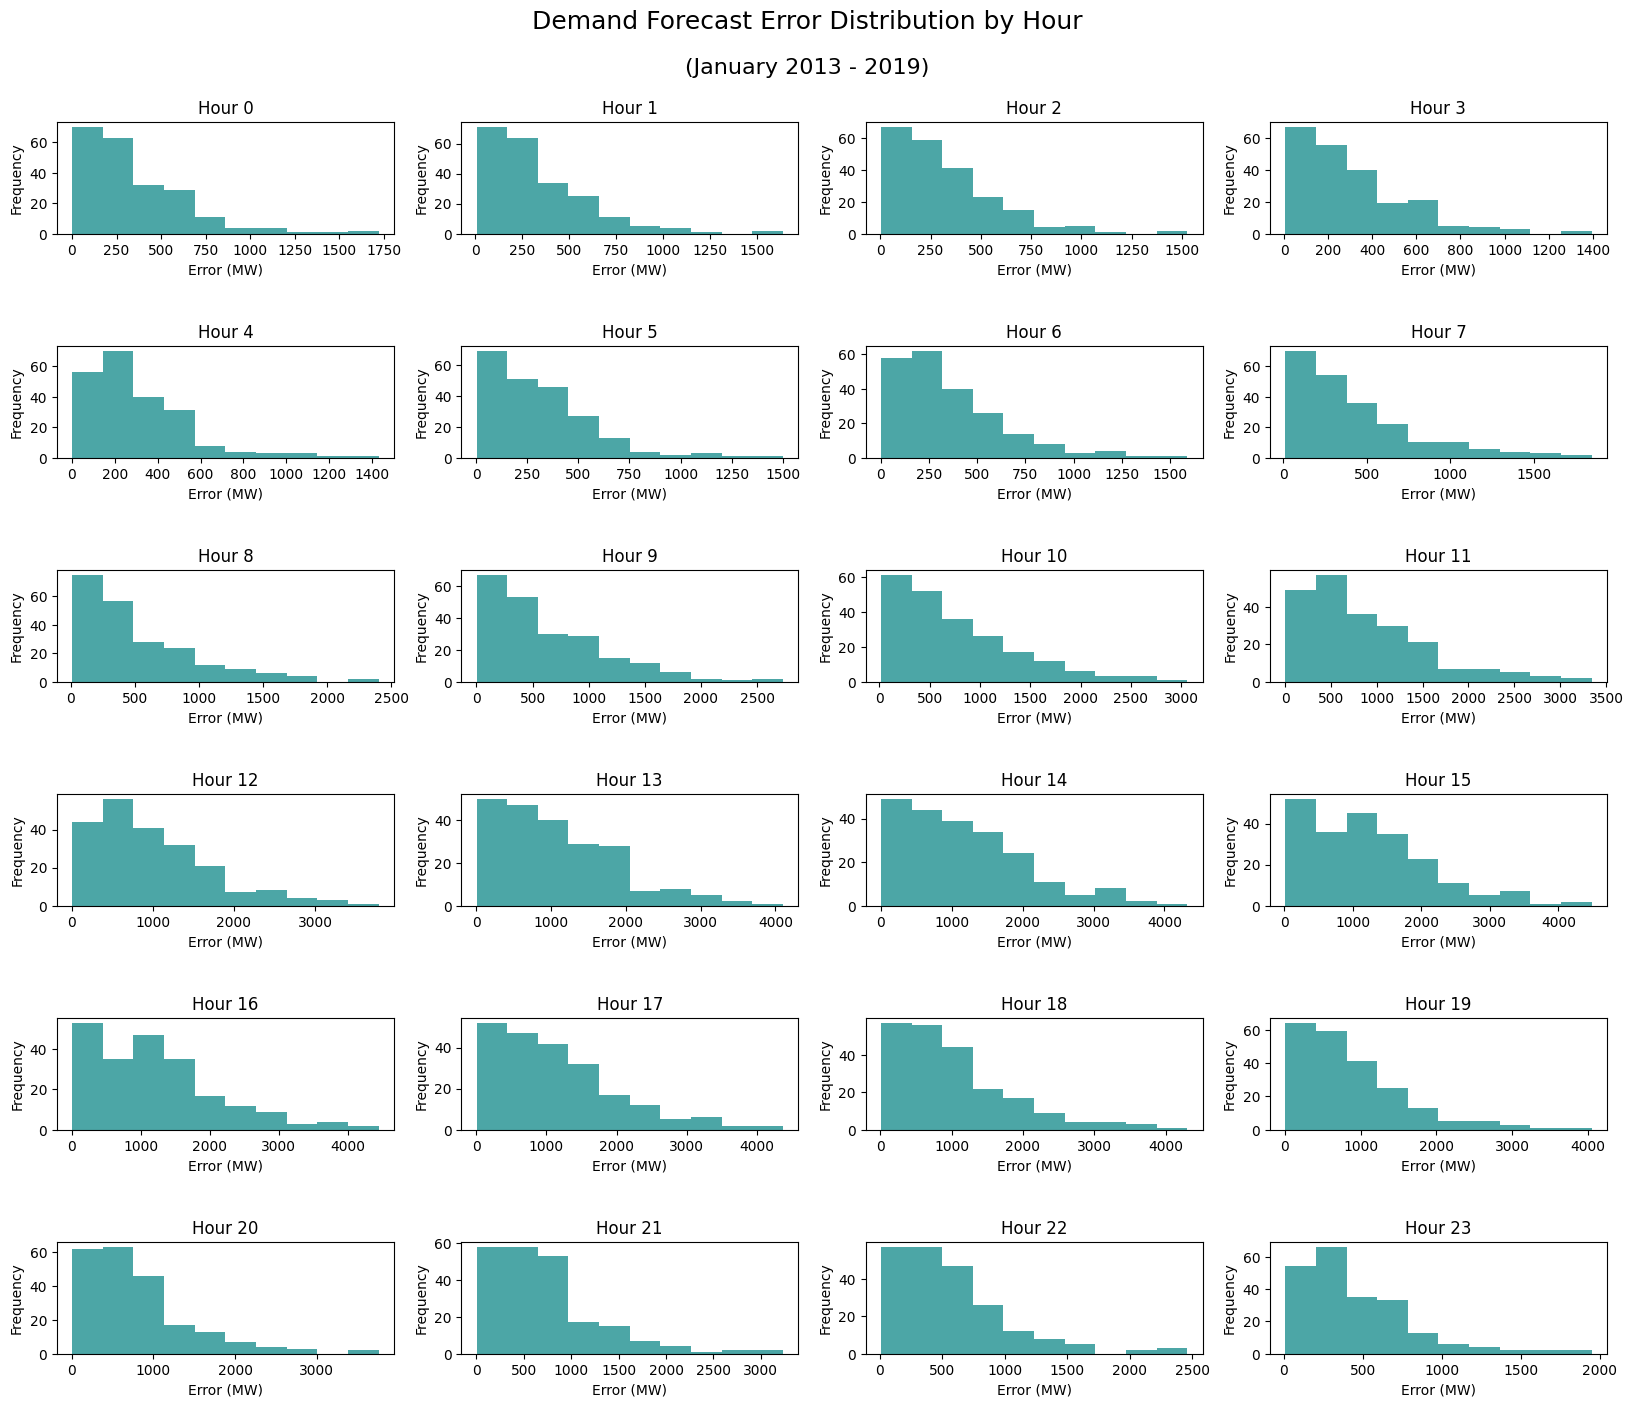

In [ ]:
# Plot type I (Histogram)

# Create a 6x4 grid of subplots for 24 hours (6 rows and 4 columns)
fig, axes = plt.subplots(6, 4, figsize=(20, 16))
fig.subplots_adjust(hspace=1)

# Iterate through the hours and create histograms
for hour, ax in zip(range(24), axes.flatten()):
    load_data = hourly_data_Jan[f'Hour_{hour}']
    ax.hist(load_data, bins=10, color='teal', alpha=0.7)
    ax.set_title(f'Hour {hour}')
    ax.set_xlabel('Error (MW)')
    ax.set_ylabel('Frequency')

# Add a title and subtitle to the figure
fig.suptitle('Demand Forecast Error Distribution by Hour', fontsize=18, y=0.95)
fig.text(0.5, 0.91, '(January 2013 - 2019)', ha='center', fontsize=16)

# Save the figure with high resolution
plt.savefig('Hourly_loaderror_distribution.png', dpi=300, bbox_inches='tight')

# Show the histograms
plt.show()

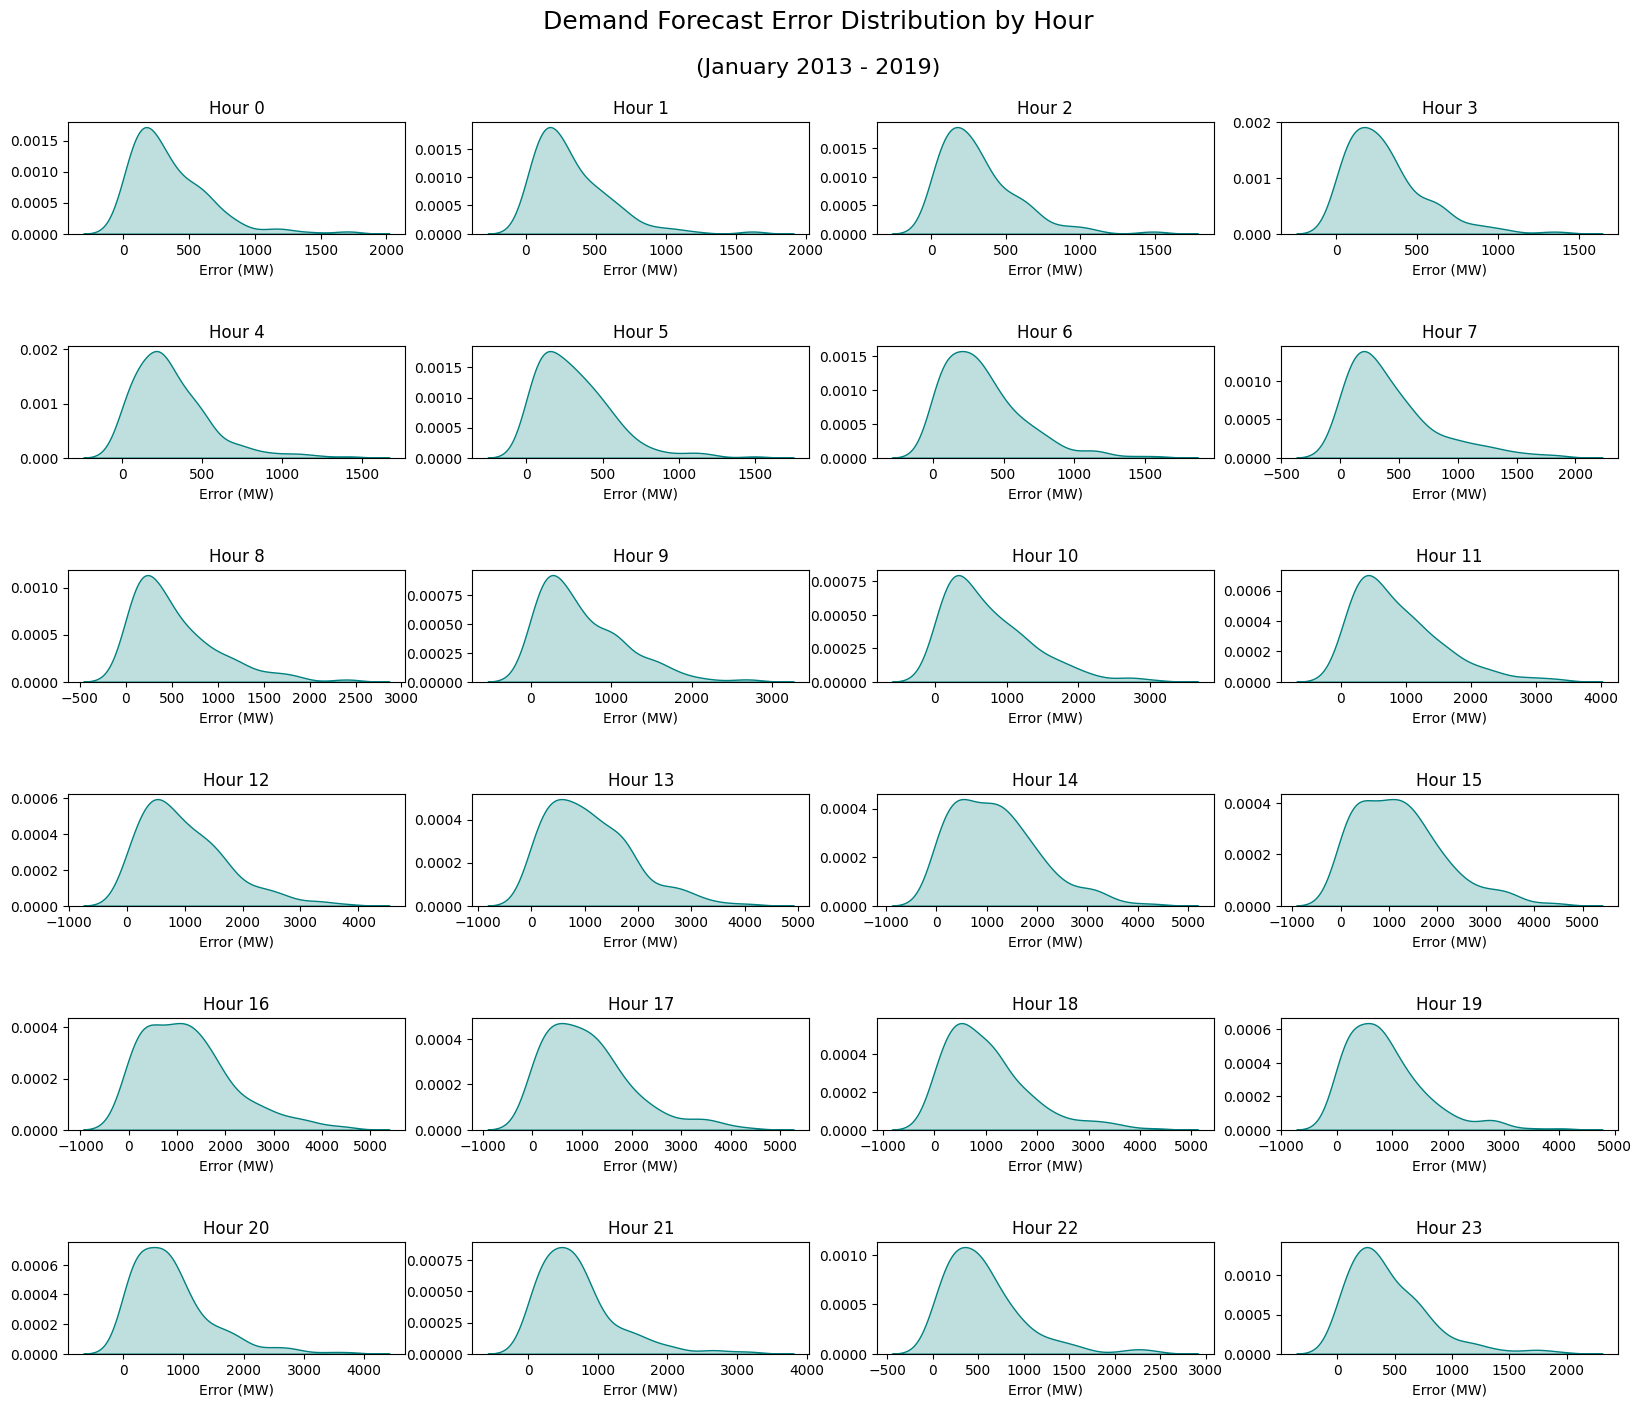

In [ ]:
# Plot type II (kernel density plot)

# Create a 6x4 grid of subplots for 24 hours (6 rows and 4 columns)
fig, axes = plt.subplots(6, 4, figsize=(20, 16))
fig.subplots_adjust(hspace=1)

# Iterate through the hours and create density plots
for hour, ax in zip(range(24), axes.flatten()):
    load_data = hourly_data_Jan[f'Hour_{hour}']
    sns.kdeplot(load_data, color='teal', fill=True, ax=ax, legend = False)
    ax.set_title(f'Hour {hour}')
    ax.set_xlabel('Error (MW)')
    ax.set_ylabel('')

# Add a title and subtitle to the figure
fig.suptitle('Demand Forecast Error Distribution by Hour', fontsize=18, y=0.95)
fig.text(0.5, 0.91, '(January 2013 - 2019)', ha='center', fontsize=16)

# Save the figure with high resolution
plt.savefig('Hourly_loaderror_distribution_density.png', dpi=300, bbox_inches='tight')

# Show the density plots
plt.show()

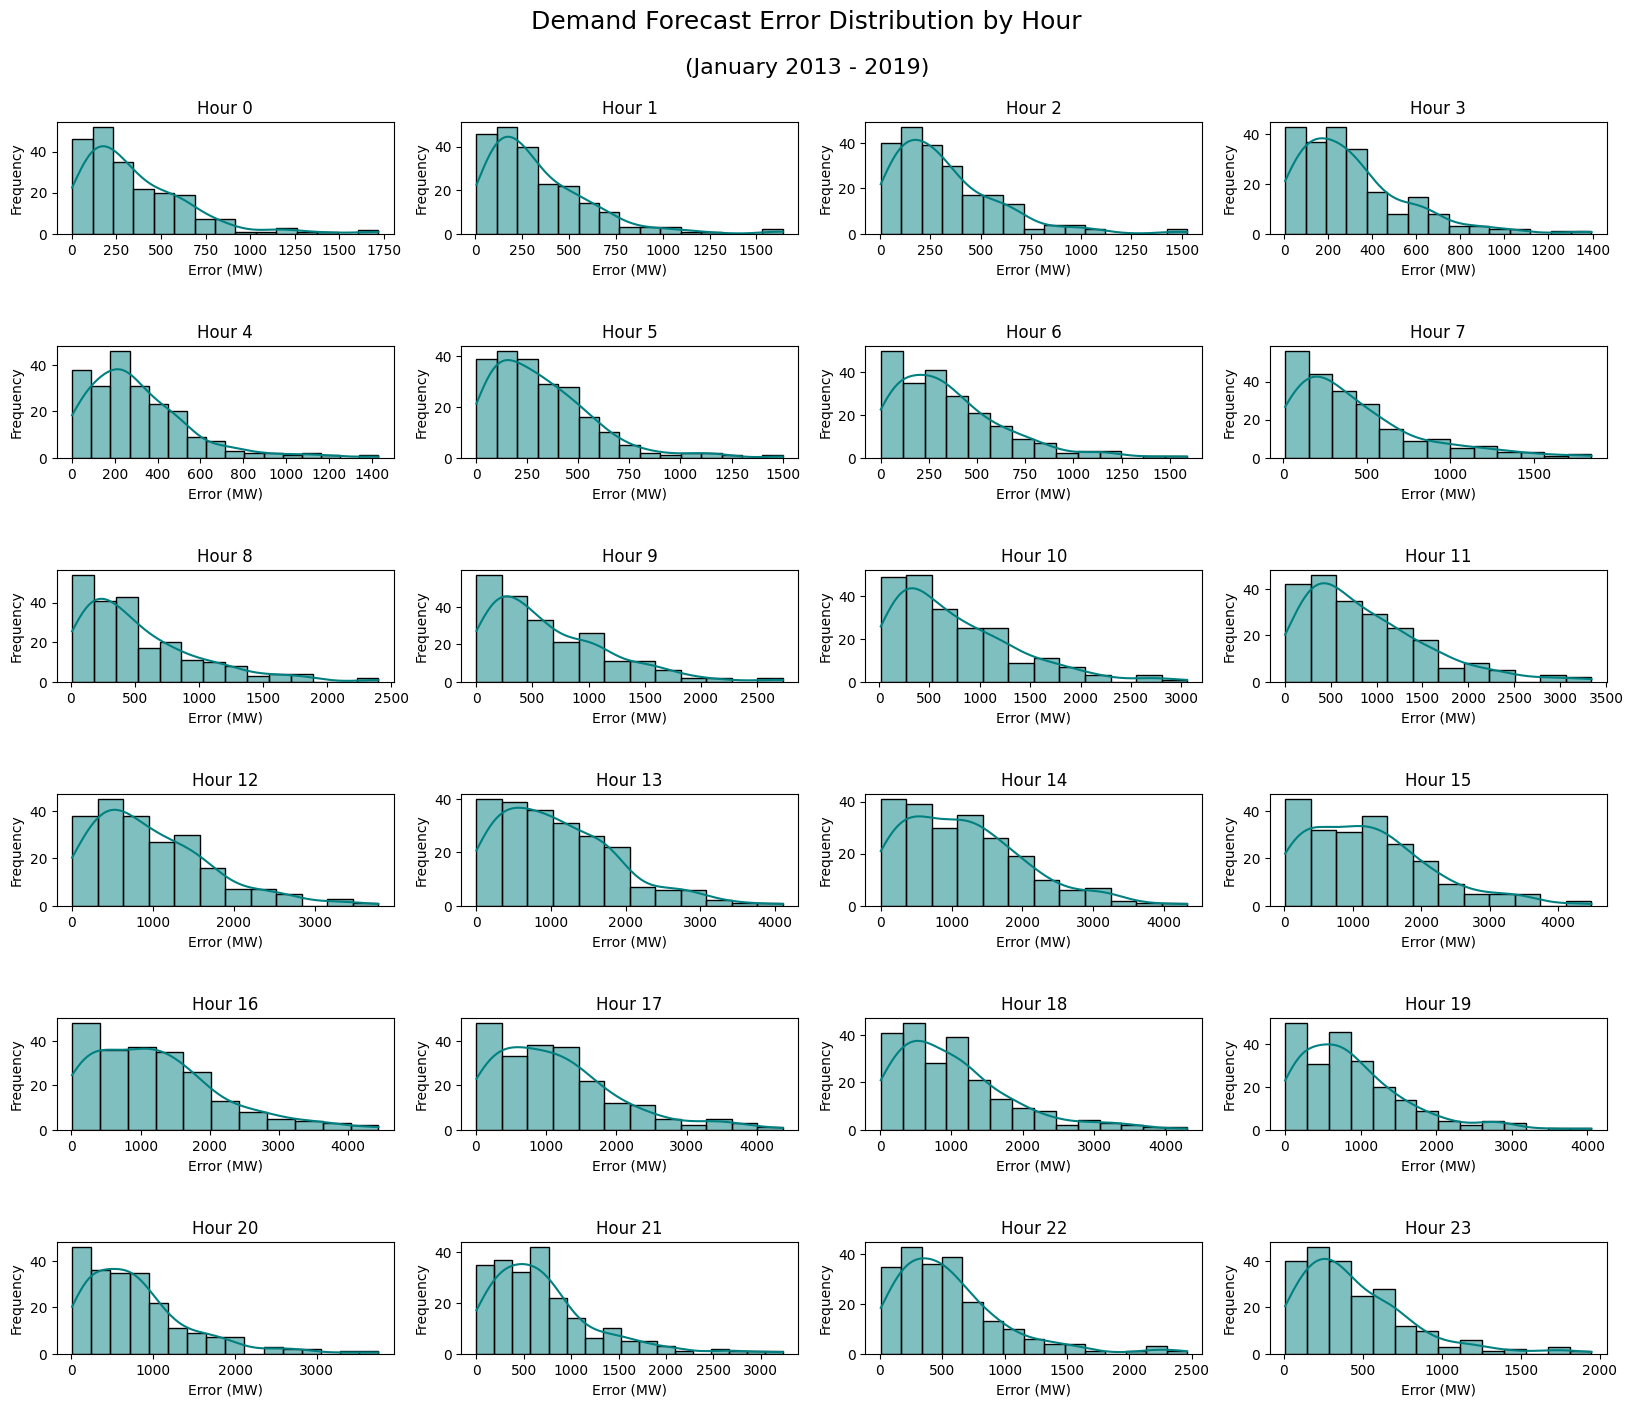

In [ ]:
# Plot type III (Histogram and kernel density plot)

# Create a 6x4 grid of subplots for 24 hours (6 rows and 4 columns)
fig, axes = plt.subplots(6, 4, figsize=(20, 16))
fig.subplots_adjust(hspace=1)

# Iterate through the hours and create histograms with KDE plots
for hour, ax in zip(range(24), axes.flatten()):
    load_data = hourly_data_Jan[f'Hour_{hour}']
    sns.histplot(load_data, kde=True, color='teal', ax=ax, legend = False)
    ax.set_title(f'Hour {hour}')
    ax.set_xlabel('Error (MW)')
    ax.set_ylabel('Frequency')

# Add a title and subtitle to the figure
fig.suptitle('Demand Forecast Error Distribution by Hour', fontsize=18, y=0.95)
fig.text(0.5, 0.91, '(January 2013 - 2019)', ha='center', fontsize=16)

# Save the figure with high resolution
plt.savefig('Hourly_loaderror_distribution_hist_and_density.png', dpi=300, bbox_inches='tight')

# Show the combined histogram and KDE plots
plt.show()

##### Goodness of fit (Load) - Testing for just the Norm distribution

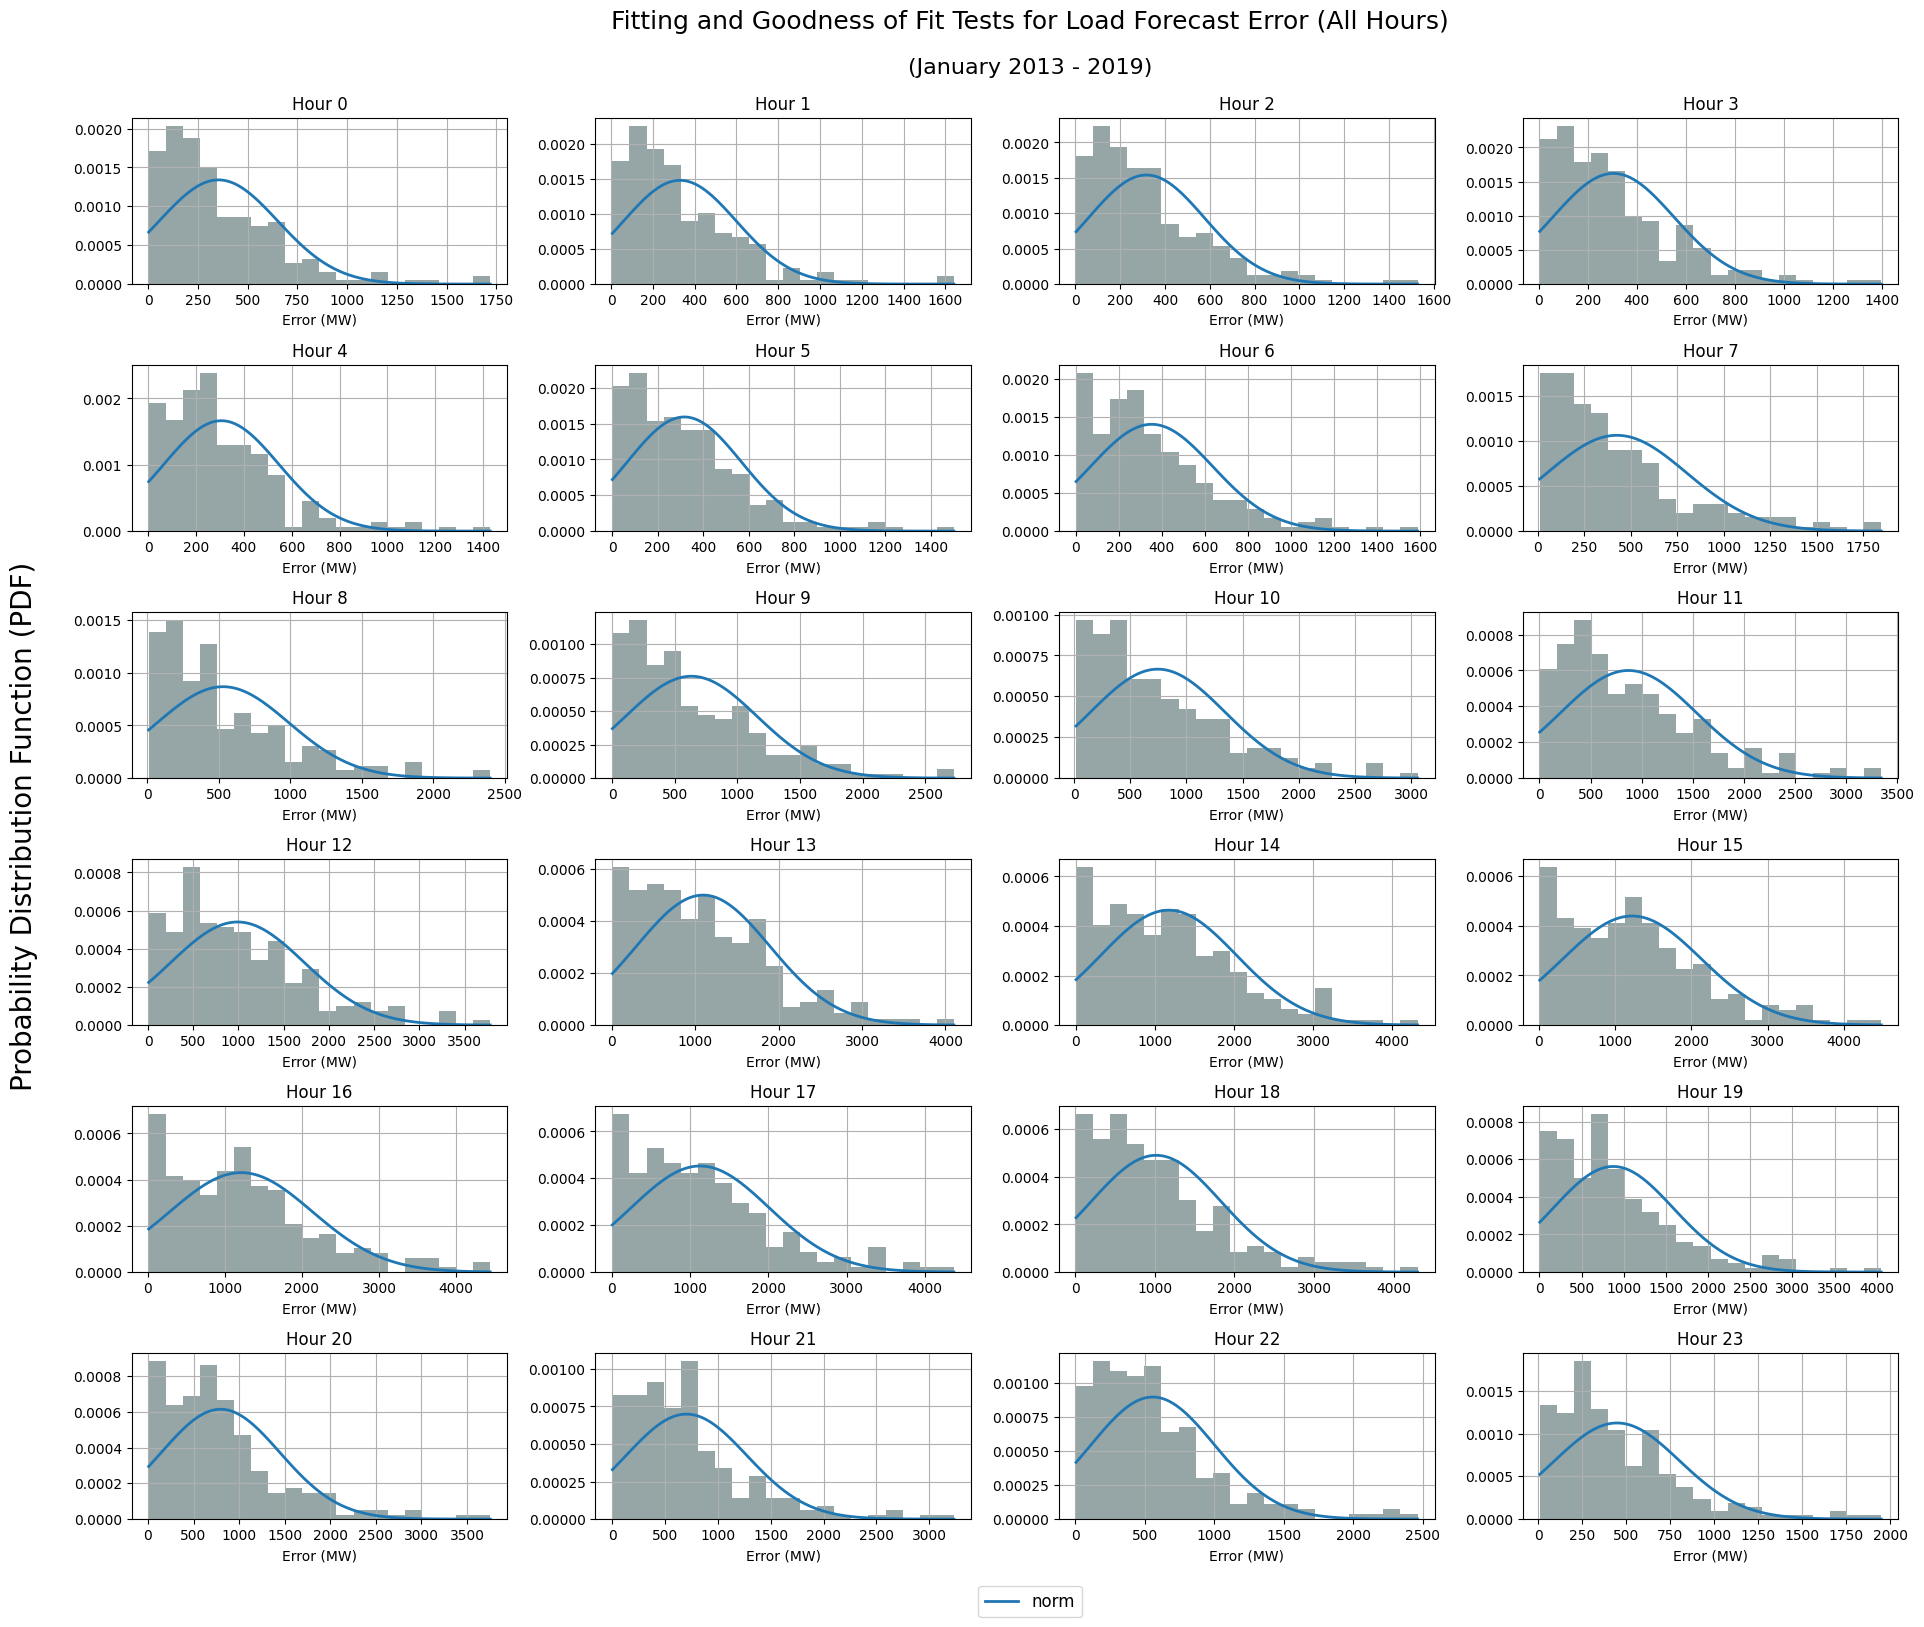

In [ ]:
# Dictionary to store goodness-of-fit statistics for each hour
load_distribution_results = {f'Hour_{hour}': {} for hour in range(24)}

# New dictionary to store parameters of each PDF fitted at each hour
pdf_parameters = {f'Hour_{hour}': {} for hour in range(24)}

# Distributions to consider
distribution_list = ['norm']

# Create a 6x4 grid of subplots for 24 hours (6 rows and 4 columns)
fig, axes = plt.subplots(6, 4, figsize=(20, 16))
fig.subplots_adjust(hspace=1)

# Iterate through the hours
for hour, ax in zip(range(24), axes.flatten()):
    # Extract the load demand data for the current hour
    hour_data = hourly_data_Jan[f'Hour_{hour}']

    # Dictionary to store parameters for this hour
    pdf_parameters_hour = {}

    # Iterate through distributions
    for distribution in distribution_list:
        # Fit the data
        if distribution in ['norm', 'lognorm']:
            params = getattr(stats, distribution).fit(hour_data)
            fitted_distribution = getattr(stats, distribution)(*params)
        else:
            params = getattr(stats, distribution).fit(hour_data)
            fitted_distribution = getattr(stats, distribution)(*params[:-2], loc=params[-2], scale=params[-1])

        # Store parameters
        pdf_parameters_hour[distribution] = params

        # Generate PDFs for the fitted distributions
        x = np.linspace(hour_data.min(), hour_data.max(), 100)
        pdf = fitted_distribution.pdf(x)

        # Perform goodness-of-fit tests
        ks_statistic, ks_p_value = stats.kstest(hour_data, distribution, args=params)
        cvm_result_obj = stats.cramervonmises(hour_data, fitted_distribution.cdf)

        # Extract statistic and p-value from CramerVonMisesResult object
        cvm_statistic, cvm_p_value = cvm_result_obj.statistic, cvm_result_obj.pvalue

        load_distribution_results[f'Hour_{hour}'][distribution.capitalize()] = {'KS': [ks_statistic, ks_p_value], 'CvM': [cvm_statistic, cvm_p_value]}

        # Plot the histogram of the data and the fitted distribution
        ax.hist(hour_data, bins=20, density=True, alpha=0.5, color='darkslategrey')
        ax.plot(x, pdf, label=distribution.capitalize(), linewidth=2.0)
        ax.set_title(f'Hour {hour}')
        ax.set_xlabel('Error (MW)')
        ax.set_ylabel('')
        ax.legend().set_visible(False)
        ax.grid()

    # Store parameters for this hour
    pdf_parameters[f'Hour_{hour}'] = pdf_parameters_hour

# Add a y-axis label to the overall figure
fig.text(-0.01, 0.5, 'Probability Distribution Function (PDF)', va='center', rotation='vertical', fontsize=20)

# List of labels for the plots
labels = distribution_list

# Add an overall legend to the figure
fig.legend(labels, loc='lower center', bbox_to_anchor=(0.5, 0), ncol=len(labels), fontsize=12)

# Add a title and subtitle to the figure
fig.suptitle('Fitting and Goodness of Fit Tests for Load Forecast Error (All Hours)', fontsize=18, y=1.01)
fig.text(0.5, 0.97, '(January 2013 - 2019)', ha='center', fontsize=16)

# Adjust the layout to make space for the overall legend
fig.tight_layout(rect=[0.01, 0.03, 0.95, 0.99])

# Save the figure with high resolution
plt.savefig('Error_Load_Fitting_and_Goodness_of_Fit_All_Hours.png', dpi=300, bbox_inches='tight')

plt.show()

In [ ]:
# Load distribution results

# Convert to DataFrame
df_load_jan = pd.DataFrame(load_distribution_results).T

# Write DataFrame to CSV
df_load_jan.to_csv('hourly_loaderror_distribution_results.csv')

In [ ]:
df_load_jan

,Norm
Hour_0,"{'KS': [0.1297220266581437, 0.0012101357043801..."
Hour_1,"{'KS': [0.1320448232079663, 0.0009263644713423..."
Hour_2,"{'KS': [0.12609287984183193, 0.001819675643817..."
Hour_3,"{'KS': [0.11971119129077157, 0.003624381503761..."
Hour_4,"{'KS': [0.1263148128615108, 0.0017754386986200..."
Hour_5,"{'KS': [0.10345391704924328, 0.017822007677262..."
Hour_6,"{'KS': [0.11193540409101277, 0.007993036584227..."
Hour_7,"{'KS': [0.1429135618770735, 0.0002489333152702..."
Hour_8,"{'KS': [0.14737145613248548, 0.000140860857325..."
Hour_9,"{'KS': [0.12579252111290468, 0.001881174507548..."


In [ ]:
# Function to expand dictionary values into separate columns
def expand_dict_values(row, column_name):
    expanded_values = row[column_name]

    for key, value in expanded_values.items():
        for i, v in enumerate(value):
            row[f"{column_name}_{key}_{i+1}"] = v
    return row

# Convert the dictionary to a DataFrame
df = pd.DataFrame(df_load_jan)

# Iterate over each PDF column and expand values
for pdf in df.columns:
    df = df.apply(lambda row: expand_dict_values(row, pdf), axis=1)

# Drop the original PDF columns
df.drop(columns=list(df_load_jan.keys()), inplace=True)

# Iterate over column names and replace '1' with 'stats' and '2' with 'pvalues'
df.columns = df.columns.str.replace('1', 'stats').str.replace('2', 'pvalues')

# Print the updated DataFrame
print(df)

         Norm_KS_stats  Norm_KS_pvalues  Norm_CvM_stats  Norm_CvM_pvalues
Hour_0        0.129722         0.001210        1.125042          0.001233
Hour_1        0.132045         0.000926        1.125532          0.001230
Hour_2        0.126093         0.001820        1.015918          0.002224
Hour_3        0.119711         0.003624        0.978230          0.002729
Hour_4        0.126315         0.001775        0.838981          0.005848
Hour_5        0.103454         0.017822        0.675439          0.014532
Hour_6        0.111935         0.007993        0.805373          0.007040
Hour_7        0.142914         0.000249        1.420922          0.000253
Hour_8        0.147371         0.000141        1.357491          0.000355
Hour_9        0.125793         0.001881        1.006314          0.002343
Hour_10       0.113245         0.007023        0.924759          0.003653
Hour_11       0.112494         0.007565        0.851880          0.005447
Hour_12       0.103552         0.01766

In [ ]:
# Keep pvalues columns

pvalues_columns = [col for col in df.columns if 'pvalues' in col]

# Subset the DataFrame with the filtered column names
df_pvalues = df[pvalues_columns].copy()

# Create a range of datetime values from 2013 to 2019
hours = ['H0', 'H1', 'H2', 'H3', 'H4', 'H5', 'H6', 'H7', 'H8', 'H9', 'H10', 'H11', 'H12', 'H13', 'H14', 'H15', 'H16', 'H17', 'H18', 'H19', 'H20', 'H21', 'H22', 'H23']

# Add the 'Year' column to the DataFrame
df_pvalues.loc[:, 'Hour'] = hours

# Rearrange the columns so that 'Year' is the first column
df_pvalues = df_pvalues[['Hour'] + [col for col in df_pvalues.columns if col != 'Hour']]

# Print the subsetted DataFrame
print(df_pvalues)

        Hour  Norm_KS_pvalues  Norm_CvM_pvalues
Hour_0    H0         0.001210          0.001233
Hour_1    H1         0.000926          0.001230
Hour_2    H2         0.001820          0.002224
Hour_3    H3         0.003624          0.002729
Hour_4    H4         0.001775          0.005848
Hour_5    H5         0.017822          0.014532
Hour_6    H6         0.007993          0.007040
Hour_7    H7         0.000249          0.000253
Hour_8    H8         0.000141          0.000355
Hour_9    H9         0.001881          0.002343
Hour_10  H10         0.007023          0.003653
Hour_11  H11         0.007565          0.005447
Hour_12  H12         0.017664          0.018997
Hour_13  H13         0.070660          0.058262
Hour_14  H14         0.073252          0.085619
Hour_15  H15         0.050253          0.076989
Hour_16  H16         0.029472          0.049264
Hour_17  H17         0.020725          0.023793
Hour_18  H18         0.011581          0.005758
Hour_19  H19         0.003886          0

In [ ]:
# Reshape the DataFrame to long format
df_long = pd.melt(df_pvalues, id_vars='Hour', var_name='PDF', value_name='Value')

# Convert 'Hour' column to categorical type to preserve order
df_long['Hour'] = pd.Categorical(df_long['Hour'], categories=['H{}'.format(i) for i in range(24)], ordered=True)

# Splitting the PDF column into two separate columns
pdf_split = df_long['PDF'].str.split('_', expand=True)

# Assigning the split columns to 'PDF' and 'Stat'
df_long['PDF'] = pdf_split[0]
df_long['Stat'] = pdf_split[1]

# Pivot the DataFrame to wide format with KS and CvM stats as separate columns
df_pivot_pvalues = df_long.pivot_table(index=['Hour', 'PDF'], columns='Stat', values='Value').reset_index()

# Rename the columns
df_pivot_pvalues.columns.name = None
df_pivot_pvalues.columns = ['Hour', 'PDF', 'CvM_pvalues', 'KS_pvalues']

print(df_pivot_pvalues)

   Hour   PDF  CvM_pvalues  KS_pvalues
0    H0  Norm     0.001233    0.001210
1    H1  Norm     0.001230    0.000926
2    H2  Norm     0.002224    0.001820
3    H3  Norm     0.002729    0.003624
4    H4  Norm     0.005848    0.001775
5    H5  Norm     0.014532    0.017822
6    H6  Norm     0.007040    0.007993
7    H7  Norm     0.000253    0.000249
8    H8  Norm     0.000355    0.000141
9    H9  Norm     0.002343    0.001881
10  H10  Norm     0.003653    0.007023
11  H11  Norm     0.005447    0.007565
12  H12  Norm     0.018997    0.017664
13  H13  Norm     0.058262    0.070660
14  H14  Norm     0.085619    0.073252
15  H15  Norm     0.076989    0.050253
16  H16  Norm     0.049264    0.029472
17  H17  Norm     0.023793    0.020725
18  H18  Norm     0.005758    0.011581
19  H19  Norm     0.004930    0.003886
20  H20  Norm     0.001643    0.001314
21  H21  Norm     0.000975    0.000344
22  H22  Norm     0.002059    0.002120
23  H23  Norm     0.003501    0.004795


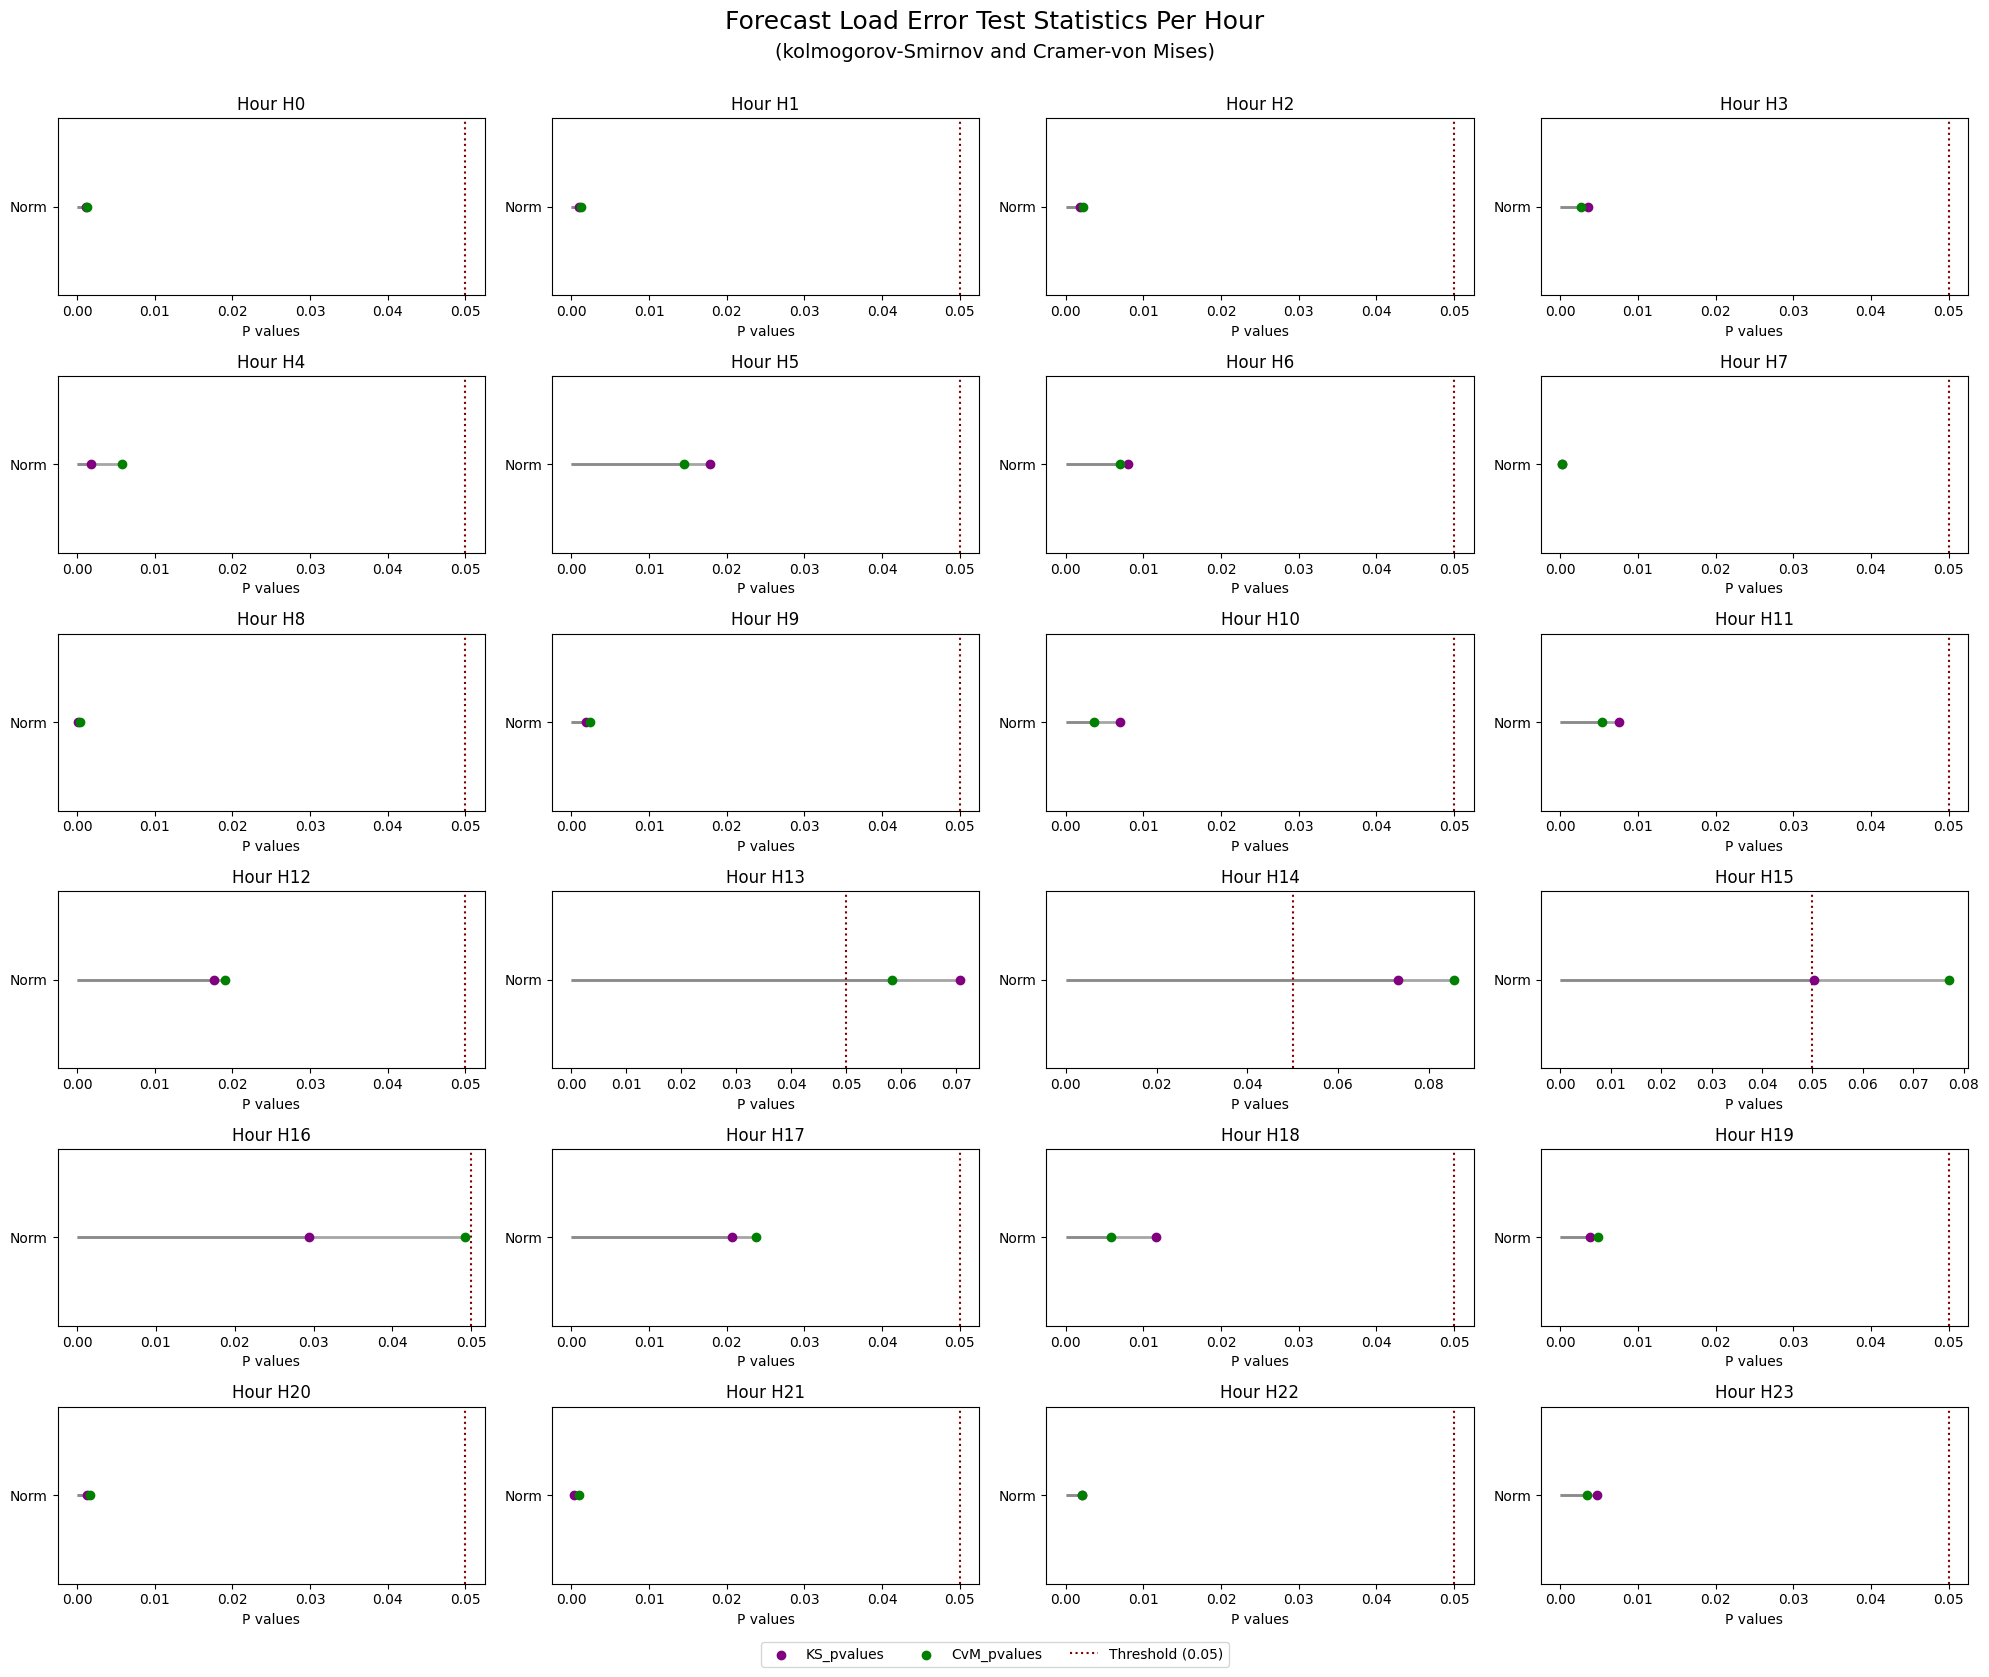

In [ ]:
# Convert data to DataFrame
df_1 = df_pivot_pvalues

# Sort DataFrame by 'KS_pvalues' and 'CvM_pvalues' in descending order
df_sorted = df_1.sort_values(by=['CvM_pvalues', 'KS_pvalues'], ascending=True)

# Create a lollipop plot
fig, axs = plt.subplots(6, 4, figsize=(20, 16))

# Flatten the axs array
axs_flat = axs.flat

# Iterate over each Hour
for i, hour in enumerate(df_1['Hour'].unique()):
    # Filter data for the current hour
    hour_data = df_sorted[df_sorted['Hour'] == hour]

    # Set up subplot
    ax = next(axs_flat)

    # Plot the KS pvalues
    ax.scatter(hour_data['KS_pvalues'], hour_data['PDF'], color='purple', label='KS_pvalues', zorder=5)
    for _, row in hour_data.iterrows():
        ax.hlines(row['PDF'], 0, row['KS_pvalues'], color='grey', alpha=0.7, linewidth=2, zorder=0)

    # Plot the CvM pvalues
    ax.scatter(hour_data['CvM_pvalues'], hour_data['PDF'], color='green', label='CvM_pvalues', zorder=5)
    for _, row in hour_data.iterrows():
        ax.hlines(row['PDF'], 0, row['CvM_pvalues'], color='grey', alpha=0.7, linewidth=2, zorder=0)

    # Set labels and title
    ax.set_xlabel('P values')
    ax.set_ylabel('')
    ax.set_title(f'Hour {hour}')

    # Place a vertical dotted line at the value of 0.05
    ax.axvline(x=0.05, color='maroon', linestyle='dotted', label='Threshold (0.05)')

    # Disable legend
    ax.legend().remove()

# Add a title and subtitle to the figure
fig.suptitle('Forecast Load Error Test Statistics Per Hour', fontsize=18, y=1.02)
fig.text(0.5, 0.99, '(kolmogorov-Smirnov and Cramer-von Mises)', ha='center', fontsize=14)

# Add legend at the bottom
handles, labels = axs[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.02), ncol=3)

# Adjust layout
plt.tight_layout()

# Save the figure with high resolution
plt.savefig('Loaderror_test_stats_per_hour.png', dpi=300, bbox_inches='tight')

plt.show()

In [ ]:
# Filtering and processing the 'stats' columns

stats_columns = [col for col in df.columns if 'stats' in col]

# Subset the DataFrame with the filtered column names
df_stats = df[stats_columns].copy()

# Create a range of datetime values from Hour 0 to Hour 23
hours = ['H0', 'H1', 'H2', 'H3', 'H4', 'H5', 'H6', 'H7', 'H8', 'H9', 'H10', 'H11', 'H12', 'H13', 'H14', 'H15', 'H16', 'H17', 'H18', 'H19', 'H20', 'H21', 'H22', 'H23']

# Add the 'Hour' column to the DataFrame
df_stats.loc[:, 'Hour'] = hours

# Rearrange the columns so that 'Year' is the first column
df_stats = df_stats[['Hour'] + [col for col in df_stats.columns if col != 'Hour']]

# Print the subsetted DataFrame
print(df_stats)

        Hour  Norm_KS_stats  Norm_CvM_stats
Hour_0    H0       0.129722        1.125042
Hour_1    H1       0.132045        1.125532
Hour_2    H2       0.126093        1.015918
Hour_3    H3       0.119711        0.978230
Hour_4    H4       0.126315        0.838981
Hour_5    H5       0.103454        0.675439
Hour_6    H6       0.111935        0.805373
Hour_7    H7       0.142914        1.420922
Hour_8    H8       0.147371        1.357491
Hour_9    H9       0.125793        1.006314
Hour_10  H10       0.113245        0.924759
Hour_11  H11       0.112494        0.851880
Hour_12  H12       0.103552        0.628062
Hour_13  H13       0.086971        0.435405
Hour_14  H14       0.086497        0.372135
Hour_15  H15       0.091327        0.389401
Hour_16  H16       0.097758        0.463537
Hour_17  H17       0.101778        0.588587
Hour_18  H18       0.108097        0.841801
Hour_19  H19       0.119046        0.870016
Hour_20  H20       0.129000        1.071845
Hour_21  H21       0.140314     

In [ ]:
# Reshaping the stats column

import pandas as pd

# Reshape the DataFrame to long format
df_long = pd.melt(df_stats, id_vars='Hour', var_name='PDF', value_name='Value')

# Convert 'Hour' column to categorical type to preserve order
df_long['Hour'] = pd.Categorical(df_long['Hour'], categories=['H{}'.format(i) for i in range(24)], ordered=True)

# Splitting the PDF column into two separate columns
pdf_split = df_long['PDF'].str.split('_', expand=True)

# Assigning the split columns to 'PDF' and 'Stat'
df_long['PDF'] = pdf_split[0]
df_long['Stat'] = pdf_split[1]

# Pivot the DataFrame to wide format with KS and CvM stats as separate columns
df_pivot_kstats = df_long.pivot_table(index=['Hour', 'PDF'], columns='Stat', values='Value').reset_index()

# Rename the columns
df_pivot_kstats.columns.name = None
df_pivot_kstats.columns = ['Hour', 'PDF', 'CvM_stats', 'KS_stats']

# Arrange PDFs in ascending order of KS_stats and CvM_stats for each year
df_pivot_kstats = df_pivot_kstats.groupby('Hour').apply(lambda x: x.sort_values(by=['CvM_stats', 'KS_stats'])).reset_index(drop=True)

# Write to a csv file
df_pivot_kstats.to_csv('Loaderror_KS_CvM_stats_All_hours.csv')

print(df_pivot_kstats)

   Hour   PDF  CvM_stats  KS_stats
0    H0  Norm   1.125042  0.129722
1    H1  Norm   1.125532  0.132045
2    H2  Norm   1.015918  0.126093
3    H3  Norm   0.978230  0.119711
4    H4  Norm   0.838981  0.126315
5    H5  Norm   0.675439  0.103454
6    H6  Norm   0.805373  0.111935
7    H7  Norm   1.420922  0.142914
8    H8  Norm   1.357491  0.147371
9    H9  Norm   1.006314  0.125793
10  H10  Norm   0.924759  0.113245
11  H11  Norm   0.851880  0.112494
12  H12  Norm   0.628062  0.103552
13  H13  Norm   0.435405  0.086971
14  H14  Norm   0.372135  0.086497
15  H15  Norm   0.389401  0.091327
16  H16  Norm   0.463537  0.097758
17  H17  Norm   0.588587  0.101778
18  H18  Norm   0.841801  0.108097
19  H19  Norm   0.870016  0.119046
20  H20  Norm   1.071845  0.129000
21  H21  Norm   1.168567  0.140314
22  H22  Norm   1.030111  0.124708
23  H23  Norm   0.932539  0.117018


<ipython-input-14-c1c0b3e1bc93>:26: FutureWarning: Not prepending group keys to the result index of transform-like apply. In the future, the group keys will be included in the index, regardless of whether the applied function returns a like-indexed object.
To preserve the previous behavior, use

	>>> .groupby(..., group_keys=False)

To adopt the future behavior and silence this warning, use 

	>>> .groupby(..., group_keys=True)
  df_pivot_kstats = df_pivot_kstats.groupby('Hour').apply(lambda x: x.sort_values(by=['CvM_stats', 'KS_stats'])).reset_index(drop=True)


In [ ]:
# PDF parameters for each fitted PDF

pdf_parameters

{'Hour_0': {'norm': (352.5845321500576, 297.6420517280012)},
 'Hour_1': {'norm': (329.4071203557028, 270.07881608892666)},
 'Hour_2': {'norm': (317.0754014256913, 259.1037634113156)},
 'Hour_3': {'norm': (304.90796073948724, 246.25161747948184)},
 'Hour_4': {'norm': (305.63390462989634, 239.86755221992914)},
 'Hour_5': {'norm': (317.4075520233295, 250.39444003737373)},
 'Hour_6': {'norm': (352.24453539026496, 283.5602457010165)},
 'Hour_7': {'norm': (426.2168067756336, 375.3840960309469)},
 'Hour_8': {'norm': (530.2115608798964, 460.01735638538577)},
 'Hour_9': {'norm': (631.9572245823733, 525.1654202375297)},
 'Hour_10': {'norm': (743.9711580141129, 598.7742844645825)},
 'Hour_11': {'norm': (870.4456078088998, 665.4457505106349)},
 'Hour_12': {'norm': (989.335481440812, 738.7321964462259)},
 'Hour_13': {'norm': (1093.4796662586407, 800.671473311611)},
 'Hour_14': {'norm': (1173.2935149949599, 859.815422549185)},
 'Hour_15': {'norm': (1223.6918661794355, 906.9093268616292)},
 'Hour_16'

In [ ]:
# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.expand_frame_repr', False)

pdf_df = pd.DataFrame(pdf_parameters).T
pdf_df

,norm
Hour_0,"(352.5845321500576, 297.6420517280012)"
Hour_1,"(329.4071203557028, 270.07881608892666)"
Hour_2,"(317.0754014256913, 259.1037634113156)"
Hour_3,"(304.90796073948724, 246.25161747948184)"
Hour_4,"(305.63390462989634, 239.86755221992914)"
Hour_5,"(317.4075520233295, 250.39444003737373)"
Hour_6,"(352.24453539026496, 283.5602457010165)"
Hour_7,"(426.2168067756336, 375.3840960309469)"
Hour_8,"(530.2115608798964, 460.01735638538577)"
Hour_9,"(631.9572245823733, 525.1654202375297)"


In [ ]:
# Unpacking PDF parameters to a 'wider' format

# Dataframe
df = pdf_df.copy()

# New DataFrame to store transformed data
new_pdf_df = pd.DataFrame()

# Function to split column based on length of content
def split_columns(hour_data, pdf_name):
    new_columns = {}
    if len(hour_data) == 2:
        new_columns[f'{pdf_name}_loc'] = hour_data[0]
        new_columns[f'{pdf_name}_scale'] = hour_data[1]
    elif len(hour_data) == 3:
        new_columns[f'{pdf_name}_shape'] = hour_data[0]
        new_columns[f'{pdf_name}_loc'] = hour_data[1]
        new_columns[f'{pdf_name}_scale'] = hour_data[2]
    elif len(hour_data) == 4:
        new_columns[f'{pdf_name}_shape1'] = hour_data[0]
        new_columns[f'{pdf_name}_shape2'] = hour_data[1]
        new_columns[f'{pdf_name}_loc'] = hour_data[2]
        new_columns[f'{pdf_name}_scale'] = hour_data[3]
    else:
        raise ValueError(f"Invalid length of content: {len(hour_data)}")
    return new_columns

# Iterate over each hour's data
for hour in range(24):
    hour_data = df.loc[f'Hour_{hour}']

    # Process each column
    for column in hour_data.index:
        pdf_name = column
        new_columns = split_columns(hour_data[column], pdf_name)

        # Add new columns to the new dataframe
        for new_column_name, new_column_data in new_columns.items():
            new_pdf_df.loc[f'Hour_{hour}', new_column_name] = new_column_data

In [ ]:
new_pdf_df

,norm_loc,norm_scale
Hour_0,352.584532,297.642052
Hour_1,329.407120,270.078816
Hour_2,317.075401,259.103763
Hour_3,304.907961,246.251617
Hour_4,305.633905,239.867552
Hour_5,317.407552,250.394440
Hour_6,352.244535,283.560246
Hour_7,426.216807,375.384096
Hour_8,530.211561,460.017356
Hour_9,631.957225,525.165420


In [ ]:
# Create a range of datetime values from 2013 to 2019
hours = ['H0', 'H1', 'H2', 'H3', 'H4', 'H5', 'H6', 'H7', 'H8', 'H9', 'H10', 'H11', 'H12', 'H13', 'H14', 'H15', 'H16', 'H17', 'H18', 'H19', 'H20', 'H21', 'H22', 'H23']

# Add the 'Year' column to the DataFrame
new_pdf_df['Hour'] = hours

# Rearrange the columns so that 'Year' is the first column
new_pdf_df = new_pdf_df[['Hour'] + [col for col in new_pdf_df.columns if col != 'Hour']]

# Print the subsetted DataFrame
print(new_pdf_df)

        Hour     norm_loc  norm_scale
Hour_0    H0   352.584532  297.642052
Hour_1    H1   329.407120  270.078816
Hour_2    H2   317.075401  259.103763
Hour_3    H3   304.907961  246.251617
Hour_4    H4   305.633905  239.867552
Hour_5    H5   317.407552  250.394440
Hour_6    H6   352.244535  283.560246
Hour_7    H7   426.216807  375.384096
Hour_8    H8   530.211561  460.017356
Hour_9    H9   631.957225  525.165420
Hour_10  H10   743.971158  598.774284
Hour_11  H11   870.445608  665.445751
Hour_12  H12   989.335481  738.732196
Hour_13  H13  1093.479666  800.671473
Hour_14  H14  1173.293515  859.815423
Hour_15  H15  1223.691866  906.909327
Hour_16  H16  1209.418596  927.412634
Hour_17  H17  1127.041607  881.300921
Hour_18  H18  1015.178437  813.429282
Hour_19  H19   874.775401  710.825347
Hour_20  H20   796.453817  649.845292
Hour_21  H21   702.403379  570.650719
Hour_22  H22   558.428844  444.978290
Hour_23  H23   447.274488  354.973643


* Process of obtaining the parameters of the **best** PDF for each hour

In [ ]:
# Get the Highest CVM and KS Pvalues for each hour.

max_indices = df_pivot_pvalues.groupby('Hour')[['CvM_pvalues']].idxmax()

# Extract rows with maximum values
max_values_df = df_pivot_pvalues.loc[max_indices.values.flatten()].reset_index(drop=True)

print(max_values_df)

   Hour   PDF  CvM_pvalues  KS_pvalues
0    H0  Norm     0.001233    0.001210
1    H1  Norm     0.001230    0.000926
2    H2  Norm     0.002224    0.001820
3    H3  Norm     0.002729    0.003624
4    H4  Norm     0.005848    0.001775
5    H5  Norm     0.014532    0.017822
6    H6  Norm     0.007040    0.007993
7    H7  Norm     0.000253    0.000249
8    H8  Norm     0.000355    0.000141
9    H9  Norm     0.002343    0.001881
10  H10  Norm     0.003653    0.007023
11  H11  Norm     0.005447    0.007565
12  H12  Norm     0.018997    0.017664
13  H13  Norm     0.058262    0.070660
14  H14  Norm     0.085619    0.073252
15  H15  Norm     0.076989    0.050253
16  H16  Norm     0.049264    0.029472
17  H17  Norm     0.023793    0.020725
18  H18  Norm     0.005758    0.011581
19  H19  Norm     0.004930    0.003886
20  H20  Norm     0.001643    0.001314
21  H21  Norm     0.000975    0.000344
22  H22  Norm     0.002059    0.002120
23  H23  Norm     0.003501    0.004795


In [ ]:
print(new_pdf_df)

        Hour     norm_loc  norm_scale
Hour_0    H0   352.584532  297.642052
Hour_1    H1   329.407120  270.078816
Hour_2    H2   317.075401  259.103763
Hour_3    H3   304.907961  246.251617
Hour_4    H4   305.633905  239.867552
Hour_5    H5   317.407552  250.394440
Hour_6    H6   352.244535  283.560246
Hour_7    H7   426.216807  375.384096
Hour_8    H8   530.211561  460.017356
Hour_9    H9   631.957225  525.165420
Hour_10  H10   743.971158  598.774284
Hour_11  H11   870.445608  665.445751
Hour_12  H12   989.335481  738.732196
Hour_13  H13  1093.479666  800.671473
Hour_14  H14  1173.293515  859.815423
Hour_15  H15  1223.691866  906.909327
Hour_16  H16  1209.418596  927.412634
Hour_17  H17  1127.041607  881.300921
Hour_18  H18  1015.178437  813.429282
Hour_19  H19   874.775401  710.825347
Hour_20  H20   796.453817  649.845292
Hour_21  H21   702.403379  570.650719
Hour_22  H22   558.428844  444.978290
Hour_23  H23   447.274488  354.973643


In [ ]:
# Where the magic happens !!!

dataset1 = max_values_df.copy()
dataset2 = new_pdf_df.copy()

# Convert PDF column in dataset1 to lowercase
dataset1['PDF'] = dataset1['PDF'].str.lower()

# Initialize dictionary to store results
results = {}

# Iterate through each row in dataset1
for index, row in dataset1.iterrows():
    hour = row['Hour']
    pdf = row['PDF']

    # Get the corresponding row from dataset2 for the current hour
    dataset2_row = dataset2.loc[dataset2['Hour'] == hour]

    # Create a dictionary to store column names and their corresponding values from dataset2
    matching_columns = {}

    # Search for columns in dataset2 for the corresponding hour that start with the PDF value
    for column in dataset2_row.columns:
        if column.lower().startswith(pdf):
            matching_columns[column] = dataset2_row.iloc[0][column]

    # Add the dictionary to the results with hour as the key
    results[hour] = matching_columns

# Print the results
for hour, columns_data in results.items():
    print(f"For Hour {hour}:")
    if columns_data:
        print("Matching Columns in dataset2:")
        for column, value in columns_data.items():
            print(f"{column}: {value}")
    else:
        print("No matching columns found in dataset2 for this hour and PDF.")
    print()

For Hour H0:
Matching Columns in dataset2:
norm_loc: 352.5845321500576
norm_scale: 297.6420517280012

For Hour H1:
Matching Columns in dataset2:
norm_loc: 329.4071203557028
norm_scale: 270.07881608892666

For Hour H2:
Matching Columns in dataset2:
norm_loc: 317.0754014256913
norm_scale: 259.1037634113156

For Hour H3:
Matching Columns in dataset2:
norm_loc: 304.90796073948724
norm_scale: 246.25161747948184

For Hour H4:
Matching Columns in dataset2:
norm_loc: 305.63390462989634
norm_scale: 239.86755221992914

For Hour H5:
Matching Columns in dataset2:
norm_loc: 317.4075520233295
norm_scale: 250.39444003737373

For Hour H6:
Matching Columns in dataset2:
norm_loc: 352.24453539026496
norm_scale: 283.5602457010165

For Hour H7:
Matching Columns in dataset2:
norm_loc: 426.2168067756336
norm_scale: 375.3840960309469

For Hour H8:
Matching Columns in dataset2:
norm_loc: 530.2115608798964
norm_scale: 460.01735638538577

For Hour H9:
Matching Columns in dataset2:
norm_loc: 631.9572245823733
nor

In [ ]:
# New dictionary with keys ranging from 0 to 23
load_data = {}

# Iterate over the original dictionary and map keys to range(24)
for hour_str, hour_data in results.items():
    # Extract the hour number from the key
    hour = int(hour_str[1:])
    load_data[hour] = hour_data

# Print the new dictionary
load_data

{0: {'norm_loc': 352.5845321500576, 'norm_scale': 297.6420517280012},
 1: {'norm_loc': 329.4071203557028, 'norm_scale': 270.07881608892666},
 2: {'norm_loc': 317.0754014256913, 'norm_scale': 259.1037634113156},
 3: {'norm_loc': 304.90796073948724, 'norm_scale': 246.25161747948184},
 4: {'norm_loc': 305.63390462989634, 'norm_scale': 239.86755221992914},
 5: {'norm_loc': 317.4075520233295, 'norm_scale': 250.39444003737373},
 6: {'norm_loc': 352.24453539026496, 'norm_scale': 283.5602457010165},
 7: {'norm_loc': 426.2168067756336, 'norm_scale': 375.3840960309469},
 8: {'norm_loc': 530.2115608798964, 'norm_scale': 460.01735638538577},
 9: {'norm_loc': 631.9572245823733, 'norm_scale': 525.1654202375297},
 10: {'norm_loc': 743.9711580141129, 'norm_scale': 598.7742844645825},
 11: {'norm_loc': 870.4456078088998, 'norm_scale': 665.4457505106349},
 12: {'norm_loc': 989.335481440812, 'norm_scale': 738.7321964462259},
 13: {'norm_loc': 1093.4796662586407, 'norm_scale': 800.671473311611},
 14: {'no

In [ ]:
import pickle

# File path to save the dictionary
file_path = "loaderror_data_norm.pickle"

# Save the dictionary to a file
with open(file_path, 'wb') as file:
    pickle.dump(load_data, file)